<a href="https://colab.research.google.com/github/nkamble-aiml/Machine-Learning/blob/main/Day%2038%20Understanding%20Neural%20Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

In [ ]:
class MultiClassNetwork:
    def __init__(self, n_features=2, n_classes=3):
        """
        Create a network for multi-class classification
        n_features: number of input features (like x1, x2)
        n_classes: number of output classes (like A, B, C)
        """
        # Instead of single weights, we have a weight MATRIX
        # Shape: (n_features, n_classes) = (2, 3)
        self.W = np.random.randn(n_features, n_classes) * 0.01

        # One bias per output neuron
        # Shape: (1, n_classes) = (1, 3)
        self.b = np.zeros((1, n_classes))

    def forward(self, X):
        """
        X: Input data, shape (n_samples, n_features)
        Returns: Probabilities for each class
        """
        # This is the magic! Matrix multiplication does ALL neurons at once
        Z = np.dot(X, self.W) + self.b
        # Z shape: (n_samples, n_classes)

        # Apply activation to get probabilities
        return self.softmax(Z)

## 5. Mathematical Notations Made Simple {#math-notations}

### 📝 Let's Decode the Math

Don't panic! We'll translate math to plain English:

#### **The Data**
```python
# Instead of scary math notation, think of it like this:
X = [[x11, x12],   # Sample 1: height=x11, weight=x12
     [x21, x22],   # Sample 2: height=x21, weight=x22
     ...]          # ... more samples

# In math: X ∈ ℝ^(m×d)
# In English: X is a table with m rows and d columns
m = 100  # number of samples (rows)
d = 2    # number of features (columns)
```

#### **The Weights**
```python
# Weight notation: w_ij means:
# - From input i
# - To neuron j

W = [[w11, w12, w13],  # Weights from input 1 to all 3 neurons
     [w21, w22, w23]]  # Weights from input 2 to all 3 neurons

# Shape: (n_features, n_classes) = (2, 3)
```

#### **The Computation**
```python
# For ONE sample going through the network:
def forward_one_sample(x, W, b):
    """
    x: one sample [x1, x2]
    W: weight matrix (2×3)
    b: bias vector [b1, b2, b3]
    """
    # Calculate weighted sum for each neuron
    z1 = x[0]*W[0,0] + x[1]*W[1,0] + b[0]  # For neuron 1
    z2 = x[0]*W[0,1] + x[1]*W[1,1] + b[1]  # For neuron 2  
    z3 = x[0]*W[0,2] + x[1]*W[1,2] + b[2]  # For neuron 3
    
    # Or more elegantly with matrix multiplication:
    z = np.dot(x, W) + b  # Does all 3 calculations at once!
    
    return z
```

### 🎯 The Key Insight

**Matrix multiplication is just a shortcut for doing many calculations at once!**

```python
# Without matrices (slow):
for sample in samples:
    for neuron in neurons:
        calculate_weighted_sum()

# With matrices (fast):
Z = np.dot(X, W) + b  # Does EVERYTHING in one line!
```

---

#### **The Data**
```python
# Instead of scary math notation, think of it like this:
X = [[x11, x12],   # Sample 1: height=x11, weight=x12
     [x21, x22],   # Sample 2: height=x21, weight=x22
     ...]          # ... more samples

# In math: X ∈ ℝ^(m×d)
# In English: X is a table with m rows and d columns
m = 100  # number of samples (rows)
d = 2    # number of features (columns)
```

#### **The Weights**
```python
# Weight notation: w_ij means:
# - From input i
# - To neuron j

W = [[w11, w12, w13],  # Weights from input 1 to all 3 neurons
     [w21, w22, w23]]  # Weights from input 2 to all 3 neurons

# Shape: (n_features, n_classes) = (2, 3)
```

In [ ]:
def binary_cross_entropy(y_true, y_pred):
    """
    y_true: Actual label (0 or 1)
    y_pred: Predicted probability (0 to 1)

    Example:
    - Truth: This IS a cat (y_true = 1)
    - Prediction: 90% sure it's a cat (y_pred = 0.9)
    - Loss: -log(0.9) = 0.105 (small loss, good!)

    - Truth: This IS a cat (y_true = 1)
    - Prediction: 10% sure it's a cat (y_pred = 0.1)
    - Loss: -log(0.1) = 2.303 (big loss, bad!)
    """
    if y_true == 1:
        return -np.log(y_pred)      # Penalize if confident but wrong
    else:
        return -np.log(1 - y_pred)   # Penalize the opposite


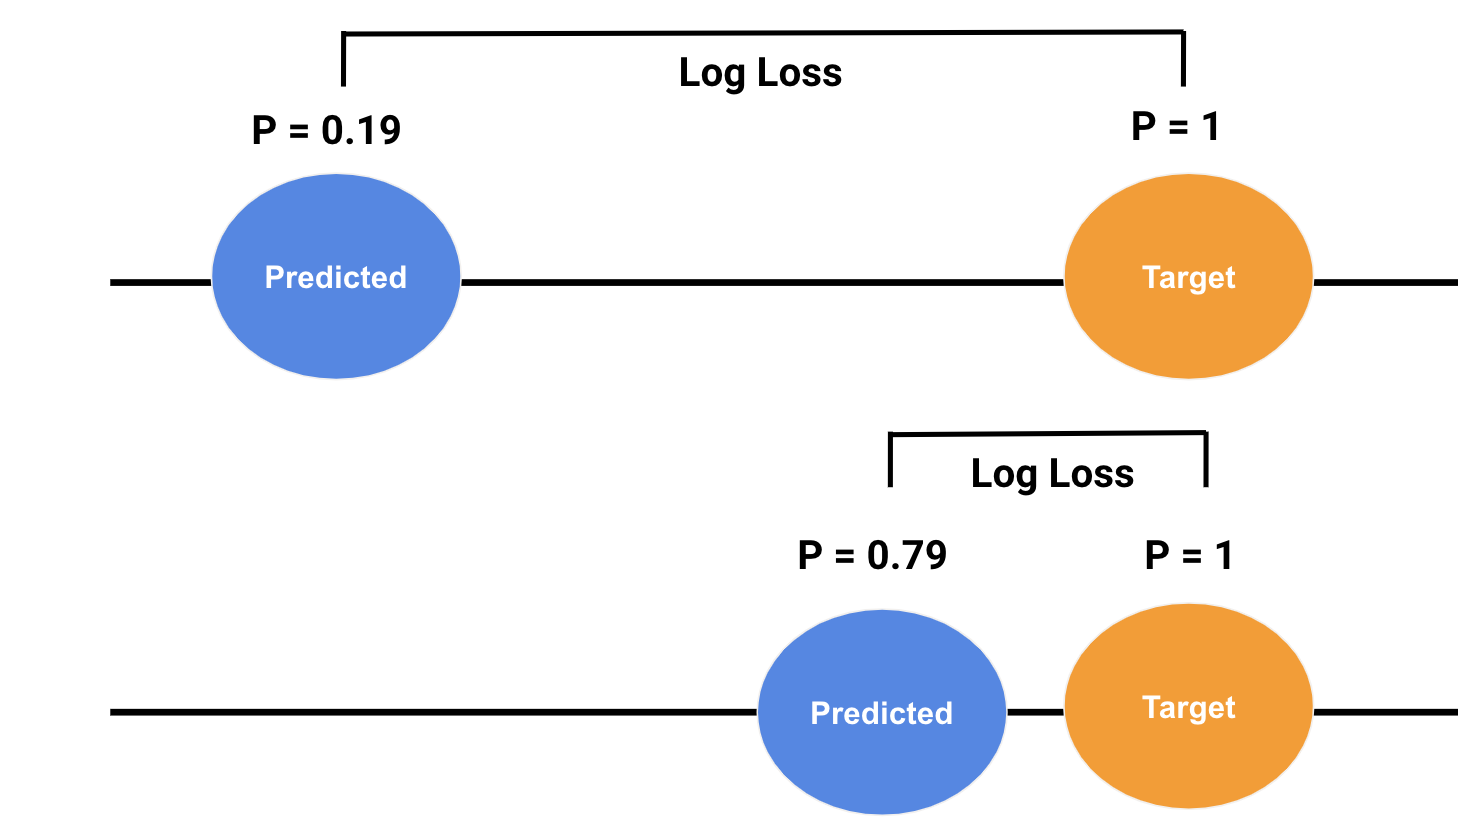

In [ ]:
def softmax(z):
    """
    Converts raw scores to probabilities that sum to 1

    Example:
    Raw scores: [2.0, 1.0, 0.1]  (Class A looks best)

    Step 1: Exponentiate (make positive, enhance differences)
    e^2.0 = 7.39, e^1.0 = 2.72, e^0.1 = 1.11

    Step 2: Normalize (make them sum to 1)
    Total = 7.39 + 2.72 + 1.11 = 11.22

    Probabilities: [0.66, 0.24, 0.10]
    Interpretation: 66% Class A, 24% Class B, 10% Class C
    """
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z)

In [ ]:
def cross_entropy_loss(y_true, y_pred):
    """
    y_true: Actual class (e.g., 2 means Class C)
    y_pred: Predicted probabilities [P(A), P(B), P(C)]

    Example:
    Truth: Class B (index 1)
    Predictions: [0.2, 0.7, 0.1]  # 70% sure it's B

    Loss = -log(0.7) = 0.357  # Not bad!

    If we were wrong:
    Predictions: [0.8, 0.1, 0.1]  # Only 10% sure it's B
    Loss = -log(0.1) = 2.303  # Much worse!
    """
    # One-hot encode the true label
    # If y_true = 1, one_hot = [0, 1, 0]
    one_hot = np.zeros_like(y_pred)
    one_hot[y_true] = 1

    # Calculate loss: -sum(truth * log(prediction))
    # Only the true class contributes (others multiply by 0)
    return -np.sum(one_hot * np.log(y_pred))

In [ ]:
import numpy as np

print("="*60)
print("🧮 NEURAL NETWORK MATH - SIMPLE EXAMPLES WITH NUMBERS")
print("="*60)

# ============================================
# PART 1: BINARY CROSS-ENTROPY (LOG LOSS)
# ============================================
print("\n" + "="*60)
print("📊 PART 1: BINARY CROSS-ENTROPY (Binary Classification)")
print("="*60)

print("\n🎯 Scenario: Classifying if an email is SPAM (1) or NOT SPAM (0)")

# Example 1: Good prediction
y_true_1 = 1  # Actual: This IS spam
y_pred_1 = 0.9  # Model says: 90% chance it's spam

print(f"\n✅ Example 1 - Good Prediction:")
print(f"   Truth: {y_true_1} (It IS spam)")
print(f"   Prediction: {y_pred_1} (90% sure it's spam)")

# Binary Cross-Entropy Formula
print(f"\n📝 Formula: Loss = -[y*log(ŷ) + (1-y)*log(1-ŷ)]")
print(f"   Where: y = true label, ŷ = predicted probability")

# Calculate step by step
term1 = y_true_1 * np.log(y_pred_1)
term2 = (1 - y_true_1) * np.log(1 - y_pred_1)
loss_1 = -(term1 + term2)

print(f"\n   Step 1: First term = {y_true_1} * log({y_pred_1})")
print(f"          = {y_true_1} * {np.log(y_pred_1):.4f}")
print(f"          = {term1:.4f}")

print(f"\n   Step 2: Second term = (1-{y_true_1}) * log(1-{y_pred_1})")
print(f"          = {1-y_true_1} * log({1-y_pred_1})")
print(f"          = {1-y_true_1} * {np.log(1-y_pred_1):.4f}")
print(f"          = {term2:.4f}")

print(f"\n   Step 3: Loss = -({term1:.4f} + {term2:.4f})")
print(f"          = -{term1:.4f}")
print(f"          = {loss_1:.4f} ✅ (Small loss - good!)")

# Example 2: Bad prediction
y_true_2 = 1  # Actual: This IS spam
y_pred_2 = 0.1  # Model says: Only 10% chance it's spam (WRONG!)

print(f"\n❌ Example 2 - Bad Prediction:")
print(f"   Truth: {y_true_2} (It IS spam)")
print(f"   Prediction: {y_pred_2} (Only 10% sure it's spam)")

term1 = y_true_2 * np.log(y_pred_2)
term2 = (1 - y_true_2) * np.log(1 - y_pred_2)
loss_2 = -(term1 + term2)

print(f"\n   Loss = -[{y_true_2}*log({y_pred_2}) + {1-y_true_2}*log({1-y_pred_2})]")
print(f"        = -[{term1:.4f} + {term2:.4f}]")
print(f"        = {loss_2:.4f} ❌ (Large loss - bad!)")

print(f"\n💡 Insight: Good prediction → Small loss ({loss_1:.4f})")
print(f"           Bad prediction → Large loss ({loss_2:.4f})")

# ============================================
# PART 2: SOFTMAX FUNCTION
# ============================================
print("\n" + "="*60)
print("🌈 PART 2: SOFTMAX (Multi-class Classification)")
print("="*60)

print("\n🎯 Scenario: Classifying an image as CAT, DOG, or BIRD")

# Raw scores from neural network (can be any values)
z = np.array([2.0, 1.0, 0.1])
classes = ['CAT', 'DOG', 'BIRD']

print(f"\n📥 Input: Raw scores (logits) from neural network")
print(f"   z = {z}")
print(f"   Classes: {classes}")

print(f"\n📝 Softmax Formula: P(class_i) = e^(z_i) / Σ(e^(z_j))")
print(f"   Converts any values → probabilities that sum to 1")

# Step 1: Exponentiate
exp_z = np.exp(z)
print(f"\n   Step 1: Exponentiate each score")
print(f"          e^{z[0]} = e^2.0 = {exp_z[0]:.4f}")
print(f"          e^{z[1]} = e^1.0 = {exp_z[1]:.4f}")
print(f"          e^{z[2]} = e^0.1 = {exp_z[2]:.4f}")

# Step 2: Sum
sum_exp = np.sum(exp_z)
print(f"\n   Step 2: Calculate sum")
print(f"          Sum = {exp_z[0]:.4f} + {exp_z[1]:.4f} + {exp_z[2]:.4f}")
print(f"              = {sum_exp:.4f}")

# Step 3: Normalize
softmax_output = exp_z / sum_exp
print(f"\n   Step 3: Divide each by sum (normalize)")
for i in range(3):
    print(f"          P({classes[i]}) = {exp_z[i]:.4f} / {sum_exp:.4f} = {softmax_output[i]:.4f}")

print(f"\n📊 Final Probabilities:")
for i in range(3):
    print(f"   {classes[i]}: {softmax_output[i]:.4f} ({softmax_output[i]*100:.1f}%)")
print(f"   Sum: {np.sum(softmax_output):.4f} ✅ (Always equals 1)")

print(f"\n💡 Insight: Highest score (2.0) → Highest probability (65.9%)")
print(f"           Softmax 'amplifies' differences between scores")

# ============================================
# PART 3: CROSS-ENTROPY LOSS (Multi-class)
# ============================================
print("\n" + "="*60)
print("🎲 PART 3: CROSS-ENTROPY LOSS (Multi-class)")
print("="*60)

print("\n🎯 Scenario: Our model predicted probabilities for CAT, DOG, BIRD")

# Predictions from softmax
predictions = softmax_output  # [0.659, 0.243, 0.099]
true_class = 0  # Actual class: CAT (index 0)

print(f"\n📥 Input:")
print(f"   Predictions: CAT={predictions[0]:.3f}, DOG={predictions[1]:.3f}, BIRD={predictions[2]:.3f}")
print(f"   True class: {classes[true_class]} (index {true_class})")

print(f"\n📝 Cross-Entropy Formula: Loss = -log(P_correct_class)")
print(f"   Only look at probability of the TRUE class")

# Calculate loss
loss = -np.log(predictions[true_class])

print(f"\n   Calculation:")
print(f"   Loss = -log(P_{classes[true_class]})")
print(f"        = -log({predictions[true_class]:.4f})")
print(f"        = -{np.log(predictions[true_class]):.4f}")
print(f"        = {loss:.4f} ✅ (Good - model was 66% confident)")

# Compare with wrong prediction
print(f"\n🔄 What if the image was actually a BIRD?")
true_class_wrong = 2  # BIRD
loss_wrong = -np.log(predictions[true_class_wrong])

print(f"   Loss = -log(P_BIRD)")
print(f"        = -log({predictions[true_class_wrong]:.4f})")
print(f"        = {loss_wrong:.4f} ❌ (Bad - model only gave 10% to BIRD)")

# ============================================
# COMPLETE EXAMPLE: MINI BATCH
# ============================================
print("\n" + "="*60)
print("🚀 COMPLETE EXAMPLE: Processing 3 Samples")
print("="*60)

# 3 samples, 3 classes each
raw_scores = np.array([
    [2.0, 1.0, 0.1],   # Sample 1 scores
    [0.5, 2.5, 0.5],   # Sample 2 scores
    [1.0, 1.0, 1.0]    # Sample 3 scores
])

true_labels = np.array([0, 1, 2])  # CAT, DOG, BIRD

print(f"\n📥 Batch Input:")
print(f"   3 samples, each with scores for 3 classes")
print(f"   Raw scores:\n{raw_scores}")
print(f"   True labels: {true_labels} (CAT, DOG, BIRD)")

# Apply softmax to each sample
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # Stable version
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

probabilities = softmax(raw_scores)

print(f"\n📊 After Softmax (probabilities):")
for i in range(3):
    print(f"   Sample {i+1}: [{probabilities[i,0]:.3f}, {probabilities[i,1]:.3f}, {probabilities[i,2]:.3f}]")
    print(f"            Predicts: {classes[np.argmax(probabilities[i])]} (highest prob)")

# Calculate cross-entropy loss for batch
losses = -np.log(probabilities[range(3), true_labels])
avg_loss = np.mean(losses)

print(f"\n📉 Cross-Entropy Loss:")
for i in range(3):
    correct_prob = probabilities[i, true_labels[i]]
    print(f"   Sample {i+1}: -log({correct_prob:.3f}) = {losses[i]:.4f}")

print(f"\n   Average Loss: {avg_loss:.4f}")

# ============================================
# KEY TAKEAWAYS
# ============================================
print("\n" + "="*60)
print("🎓 KEY TAKEAWAYS")
print("="*60)

print("""
1️⃣ BINARY CROSS-ENTROPY:
   • For 2 classes (0 or 1)
   • Penalizes wrong predictions heavily
   • Loss = -[y*log(ŷ) + (1-y)*log(1-ŷ)]

2️⃣ SOFTMAX:
   • Converts any values → probabilities
   • Always sum to 1
   • Amplifies differences (winner takes most)

3️⃣ CROSS-ENTROPY (Multi-class):
   • For 3+ classes
   • Only looks at probability of correct class
   • Loss = -log(P_correct)

4️⃣ WHY LOG?
   • log(1) = 0 → Perfect prediction = 0 loss
   • log(0.1) = -2.3 → Bad prediction = High loss
   • Gradient properties perfect for learning
""")

print("="*60)
print("✅ Copy this code to Colab and experiment with different values!")
print("="*60)

🧮 NEURAL NETWORK MATH - SIMPLE EXAMPLES WITH NUMBERS

📊 PART 1: BINARY CROSS-ENTROPY (Binary Classification)

🎯 Scenario: Classifying if an email is SPAM (1) or NOT SPAM (0)

✅ Example 1 - Good Prediction:
   Truth: 1 (It IS spam)
   Prediction: 0.9 (90% sure it's spam)

📝 Formula: Loss = -[y*log(ŷ) + (1-y)*log(1-ŷ)]
   Where: y = true label, ŷ = predicted probability

   Step 1: First term = 1 * log(0.9)
          = 1 * -0.1054
          = -0.1054

   Step 2: Second term = (1-1) * log(1-0.9)
          = 0 * log(0.09999999999999998)
          = 0 * -2.3026
          = -0.0000

   Step 3: Loss = -(-0.1054 + -0.0000)
          = --0.1054
          = 0.1054 ✅ (Small loss - good!)

❌ Example 2 - Bad Prediction:
   Truth: 1 (It IS spam)
   Prediction: 0.1 (Only 10% sure it's spam)

   Loss = -[1*log(0.1) + 0*log(0.9)]
        = -[-2.3026 + -0.0000]
        = 2.3026 ❌ (Large loss - bad!)

💡 Insight: Good prediction → Small loss (0.1054)
           Bad prediction → Large loss (2.3026)

🌈 PART

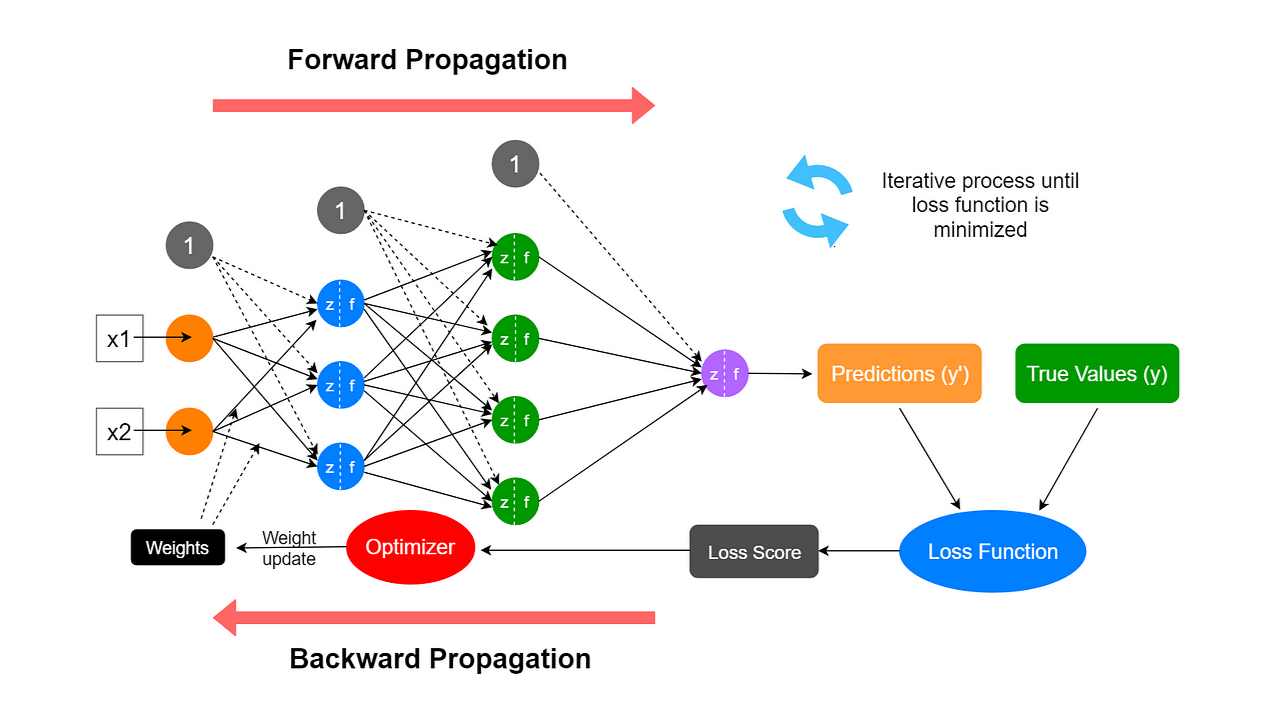

In [ ]:
class NeuralNetwork:
    def __init__(self, input_size=2, output_size=3):
        """Initialize our baby neural network"""
        # Random small weights (like random guesses to start)
        self.W = np.random.randn(input_size, output_size) * 0.01
        # Zeros for bias (neutral starting point)
        self.b = np.zeros((1, output_size))

    def forward_propagation(self, X):
        """
        The complete forward pass - data goes in, predictions come out!

        X: Input data, shape (n_samples, n_features)
           Example: [[1.5, 2.0],   # Sample 1
                     [0.5, 1.0]]   # Sample 2
        """
        # Step 1: Linear transformation (weighted sum)
        # Like mixing ingredients with different proportions
        self.Z = np.dot(X, self.W) + self.b

        print(f"Step 1 - Linear combination Z:")
        print(f"Shape: {self.Z.shape}")
        print(f"Values: {self.Z[:2]}")  # Show first 2 samples

        # Step 2: Apply softmax (convert to probabilities)
        # Like baking - raw ingredients become something useful!
        self.A = self.softmax(self.Z)

        print(f"\nStep 2 - After softmax A:")
        print(f"Shape: {self.A.shape}")
        print(f"Values: {self.A[:2]}")
        print(f"Sum of probabilities: {np.sum(self.A[0])}")  # Should be 1.0

        return self.A

    def softmax(self, Z):
        """Convert scores to probabilities"""
        # Trick: Subtract max for numerical stability
        # (Prevents overflow with large numbers)
        exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

In [ ]:
# Create a mini dataset
X = np.array([[1.0, 2.0],    # Point in 2D space
              [0.5, 1.5],
              [2.0, 1.0]])

# Create and run our network
nn = NeuralNetwork(input_size=2, output_size=3)
predictions = nn.forward_propagation(X)

# Interpret the results
for i, pred in enumerate(predictions):
    print(f"\nSample {i+1}:")
    print(f"  Class A: {pred[0]:.2%} probability")
    print(f"  Class B: {pred[1]:.2%} probability")
    print(f"  Class C: {pred[2]:.2%} probability")
    print(f"  Predicted class: {np.argmax(pred)}")

Step 1 - Linear combination Z:
Shape: (3, 3)
Values: [[-0.01641544 -0.02995447 -0.03976485]
 [-0.01461287 -0.02355466 -0.02669349]]

Step 2 - After softmax A:
Shape: (3, 3)
Values: [[0.33744188 0.33290403 0.32965409]
 [0.33567296 0.33268482 0.33164222]]
Sum of probabilities: 1.0

Sample 1:
  Class A: 33.74% probability
  Class B: 33.29% probability
  Class C: 32.97% probability
  Predicted class: 0

Sample 2:
  Class A: 33.57% probability
  Class B: 33.27% probability
  Class C: 33.16% probability
  Predicted class: 0

Sample 3:
  Class A: 33.98% probability
  Class B: 33.51% probability
  Class C: 32.51% probability
  Predicted class: 0


In [ ]:
#break : 9 15 pm

## 8. Backward Propagation - The Magic Behind Learning {#backward-propagation}

### 🎯 The Big Idea

Imagine you're learning to throw darts:
1. You throw (forward propagation)
2. You see how far off you were (calculate loss)
3. You adjust your technique (backward propagation)
4. Try again with the adjustment (update weights)

### 🔄 The Chain Rule - Breaking Down Complex Problems
```python
"""
The Chain Rule in Plain English:

If you want to know: "How does changing weights affect the loss?"
Break it down:
1. How does changing weights affect Z? (Easy: dZ/dW = X)
2. How does changing Z affect probabilities? (Softmax derivative)
3. How does changing probabilities affect loss? (Cross-entropy derivative)

Then multiply them together!
dL/dW = dL/dA * dA/dZ * dZ/dW
"""

self.Z = np.dot(X, self.W) + self.b  # Calculate scores
self.A = self.softmax(self.Z)

In [ ]:
#self.Z = np.dot(X, self.W) + self.b  # Calculate scores
#self.A = self.softmax(self.Z)

In [ ]:
#correct_probs = self.A[range(m), y_true]
#loss = -np.mean(np.log(correct_probs))

In [ ]:
#self.dZ = self.A.copy()
#self.dZ[range(m), y_true] -= 1  # The magic formula!

**The Magic Formula Explained:**
- Take your predictions: [0.7, 0.2, 0.1]
- Subtract 1 from the CORRECT answer
- If correct was class 1 (dog): [0.7, -0.8, 0.1]

**What do these numbers mean?**
- **Positive (+0.7)** = "You gave too much to CAT, reduce it!"
- **Negative (-0.8)** = "You gave too little to DOG, increase it!"
- **Small (+0.1)** = "You gave a bit too much to BIRD"

#### **4️⃣ Update Weights** (Fix Our Mistakes)
```python
self.W = self.W - learning_rate * self.dW
```
- Adjust the "importance knobs" (weights)
- Like adjusting your throwing angle after missing the dartboard

---

### 🎨 **Real Example with Numbers**

**Scenario:** Network sees a picture of a DOG

**What happens:**
1. **Network guesses:**
   - Cat: 70% ❌ (wrong!)
   - Dog: 20% ✅ (correct but too low)
   - Bird: 10% ❌

2. **Calculate error signal (dZ):**
   - Cat: +0.7 → "Reduce cat score by a lot!"
   - Dog: -0.8 → "Increase dog score by a lot!"
   - Bird: +0.1 → "Reduce bird score a little"

3. **Update weights:**
   - Weights that led to "cat" get reduced
   - Weights that lead to "dog" get increased
   - Network learns: "Next time I see these features, think DOG not CAT!"

---

### 💡 **The Simple Intuition**

**Backpropagation is like a teacher correcting homework:**

1. **Student writes:** C-A-T
2. **Teacher marks:** ❌ It's D-O-G
3. **Student learns:**
   - "Don't write C when I see four legs and barking"
   - "Do write D when I see these features"

The network adjusts its "rules" (weights) based on mistakes!

---

### 🔄 **Why It Works**

**Every training example:**
- Shows network its mistakes
- Network adjusts slightly
- After thousands of examples, it gets really good!

**It's exactly like:**
- Learning to ride a bike (fall left → lean right)
- Learning to cook (too salty → use less salt)
- Learning to write (messy → practice more)

---

### 📊 **The Gradient (Direction to Improve)**

```
Gradient = Prediction - Truth
```

**If you predicted 70% cat but it was 0% cat:**
- Gradient = 0.7 - 0 = +0.7
- Positive = "Go down!" (reduce cat probability)

**If you predicted 20% dog but it was 100% dog:**
- Gradient = 0.2 - 1.0 = -0.8  
- Negative = "Go up!" (increase dog probability)

---

### 🎯 **In One Sentence**

**Backpropagation = The network looking at its mistakes and adjusting its "guessing rules" to be less wrong next time!**

Just like you learning from experience:
- Touch hot stove → Learn "don't touch red coils"
- Eat sour lemon → Learn "yellow citrus = sour"
- See this pattern → Learn "four legs + barks = dog"

The network does the same thing, just with numbers! 🚀

## 🎯 **Let's Connect the Math to the Code - Simple Explanation**

You're right! You know the theory. Let me show you **EXACTLY** how the code connects to what you already know.

---

### 📚 **What You Already Know (The Theory)**

1. We need: **∂Loss/∂W** (how loss changes with weights)
2. Then update: **W_new = W_old - lr × (∂Loss/∂W)**

**But the problem is:** Loss doesn't directly connect to W. It goes through steps:
```
W → Z → A (softmax) → Loss
```

So we use **chain rule** to work backwards!

---

## 🔗 **The Chain Rule Path**

To get **∂Loss/∂W**, we need:
```
∂Loss/∂W = ∂Loss/∂Z × ∂Z/∂W
```

Let's find each part:

---

## 📊 **Part 1: Why We Subtract 1 (Finding ∂Loss/∂Z)**

### **The Math Behind It**

For cross-entropy loss with softmax, the derivative is surprisingly simple:

```
∂Loss/∂Z = A - Y_true
```

Where:
- **A** = our predictions (probabilities)
- **Y_true** = one-hot encoded truth

### **Example with Numbers:**

**Sample 1 (actual = Cat):**
- Predictions A = [0.24, 0.32, 0.44]
- Truth one-hot = [1, 0, 0] (it's a cat)
- **∂Loss/∂Z = [0.24-1, 0.32-0, 0.44-0] = [-0.76, 0.32, 0.44]**

**This is exactly what the code does!**
```python
self.dZ = self.A.copy()           # Start with predictions
self.dZ[range(m), y_true] -= 1    # Subtract 1 from true class position
```

### **Why This Makes Sense:**
- **-0.76 for Cat**: Negative = "Increase this!" (we only gave 24% but it should be 100%)
- **+0.32 for Dog**: Positive = "Decrease this!" (we gave 32% but it should be 0%)
- **+0.44 for Bird**: Positive = "Decrease this!" (we gave 44% but it should be 0%)

---

## 🧮 **Part 2: Finding ∂Z/∂W**

Remember: **Z = X × W + b**

So: **∂Z/∂W = X** (the derivative of XW with respect to W is just X!)

---

## 🔄 **Part 3: Combining Everything (Finding dW)**

Using chain rule:
```
∂Loss/∂W = ∂Loss/∂Z × ∂Z/∂W
         = dZ × X
         = X^T × dZ  (we transpose for matrix multiplication)
```

**This is exactly:**
```python
self.dW = np.dot(X.T, self.dZ)
```

---

## 📝 **Simple Step-by-Step Example**

Let's trace one weight update:

### **Starting Point:**
- Image features: X = [1, 2]
- Current weight: W[0,0] = 0.1 (connects input 1 to Cat output)
- Network predicted: 24% Cat
- Truth: 100% Cat (it IS a cat!)

### **Step 1: Calculate Error Signal**
```
dZ for Cat = 0.24 - 1.0 = -0.76
```
"You were 76% too low on Cat!"

### **Step 2: Calculate Weight Gradient**
```
dW[0,0] = X[0] × dZ[Cat]
        = 1 × (-0.76)
        = -0.76
```
"This weight contributed -0.76 to the error"

### **Step 3: Update Weight**
```
W[0,0]_new = W[0,0]_old - lr × dW[0,0]
           = 0.1 - 0.1 × (-0.76)
           = 0.1 + 0.076
           = 0.176
```
"Increase this weight to make Cat score higher next time!"

---

## 💡 **The Complete Picture in Simple Terms**

```python
# What we're really doing:

# 1. FORWARD: Make a guess
prediction = [0.24, 0.32, 0.44]  # "I think: 24% cat, 32% dog, 44% bird"

# 2. ERROR: How wrong were we?
truth = [1, 0, 0]  # "It's 100% cat!"
error = prediction - truth  # [-0.76, 0.32, 0.44]
# Means: "Add 76% to cat, remove 32% from dog, remove 44% from bird"

# 3. BLAME: Which weights caused this error?
# If input was [1, 2] and error was [-0.76, 0.32, 0.44]
# Then weight from input1→cat contributed: 1 × (-0.76) = -0.76

# 4. FIX: Adjust weights opposite to gradient
# If gradient is negative (-0.76), we ADD to weight
# If gradient is positive (+0.44), we SUBTRACT from weight
```

---

## 🎯 **Why This Specific Formula Works**

The magical formula `dZ = predictions - truth` comes from calculus, but here's the intuition:

**If you predicted 30% but truth is 100%:**
- Error = 30% - 100% = -70%
- Negative means "go UP"
- Update will increase this weight

**If you predicted 80% but truth is 0%:**
- Error = 80% - 0% = +80%
- Positive means "go DOWN"
- Update will decrease this weight

---

## 📊 **Visual Summary**

```
FORWARD PASS:
X --W--> Z --softmax--> A --loss--> L

BACKWARD PASS (derivatives):
L --∂L/∂A--> A --∂A/∂Z--> Z --∂Z/∂W--> W

ACTUAL CALCULATION:
1. dZ = A - Y_true        (error at output)
2. dW = X^T × dZ          (error for each weight)
3. W_new = W - lr × dW    (fix the weights)
```

---

## 🚀 **In One Sentence**

**We subtract 1 from the true class because that's the derivative of cross-entropy loss with softmax - it tells us "how wrong we were" for each class, which we then use to figure out "which weights to blame" and "how to fix them"!**

It's like:
- **Teacher marks your test**: "You got 24/100 on question 1" (dZ)
- **You figure out why**: "I didn't study chapter 3" (dW)
- **You fix it**: "Study chapter 3 more" (update W)

Does this make the connection clearer? The code is just implementing the calculus chain rule in a clever, simplified way! 🎓

In [ ]:
class NeuralNetworkWithBackprop:
    def __init__(self, input_size=2, output_size=3, learning_rate=0.1):
        self.W = np.random.randn(input_size, output_size) * 0.01
        self.b = np.zeros((1, output_size))
        self.learning_rate = learning_rate

    def forward(self, X):
        """Same as before - calculate predictions"""
        self.Z = np.dot(X, self.W) + self.b
        self.A = self.softmax(self.Z)
        return self.A

    def calculate_loss(self, y_true):
        """Calculate how wrong we were"""
        m = len(y_true)
        # Pick the probability of the correct class for each sample
        correct_probs = self.A[range(m), y_true]
        # Take negative log (cross-entropy)
        loss = -np.mean(np.log(correct_probs + 1e-7))  # Add tiny value to avoid log(0)
        return loss

    def backward(self, X, y_true):
        """
        The magic happens here! Calculate gradients.

        The math looks scary but the intuition is simple:
        - For the correct class: push probability UP (toward 1)
        - For wrong classes: push probability DOWN (toward 0)
        """
        m = len(y_true)

        # Step 1: Calculate dZ (gradient of loss w.r.t. Z)
        # This has a beautiful closed form: probabilities - one_hot(truth)
        self.dZ = self.A.copy()
        self.dZ[range(m), y_true] -= 1  # Subtract 1 from true class
        self.dZ = self.dZ / m  # Average over batch

        print("🔄 BACKWARD PROPAGATION:")
        print(f"  dZ (error signal) first sample: {self.dZ[0]}")
        print(f"  Interpretation:")
        print(f"    Positive → reduce this probability")
        print(f"    Negative → increase this probability")

        # Step 2: Calculate dW (gradient of loss w.r.t. weights)
        # How much each weight contributed to the error
        self.dW = np.dot(X.T, self.dZ)

        print(f"\n  dW shape: {self.dW.shape}")
        print(f"  Weight gradient for first input→first output: {self.dW[0,0]:.4f}")

        # Step 3: Calculate db (gradient of loss w.r.t. bias)
        self.db = np.sum(self.dZ, axis=0, keepdims=True)

        print(f"\n  db (bias gradients): {self.db[0]}")

    def update_parameters(self):
        """
        Adjust weights and biases based on gradients.
        Like adjusting your dart throw based on where you missed.
        """
        print("\n📊 PARAMETER UPDATE:")
        print(f"  Old weight[0,0]: {self.W[0,0]:.4f}")

        # Gradient descent: take a small step opposite to gradient
        self.W = self.W - self.learning_rate * self.dW
        self.b = self.b - self.learning_rate * self.db

        print(f"  New weight[0,0]: {self.W[0,0]:.4f}")
        print(f"  Change: {-self.learning_rate * self.dW[0,0]:.4f}")

    def softmax(self, Z):
        exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

In [ ]:
def understand_gradient():
    """
    Let's see WHY dZ = predictions - truth makes sense
    """
    # Example: 3 classes
    predictions = np.array([0.7, 0.2, 0.1])  # Network thinks it's class 0
    true_class = 0  # It's actually class 0 (good guess!)

    # Calculate gradient
    gradient = predictions.copy()
    gradient[true_class] -= 1
    # Result: [-0.3, 0.2, 0.1]

    print("When CORRECT (predicted class 0, actual class 0):")
    print(f"  Gradients: {gradient}")
    print("  Interpretation:")
    print("    Class 0: -0.3 → increase this probability (it's correct!)")
    print("    Class 1: +0.2 → decrease this probability")
    print("    Class 2: +0.1 → decrease this probability")

    # Now if we were wrong:
    predictions = np.array([0.7, 0.2, 0.1])  # Network thinks it's class 0
    true_class = 1  # But it's actually class 1!

    gradient = predictions.copy()
    gradient[true_class] -= 1
    # Result: [0.7, -0.8, 0.1]

    print("\nWhen WRONG (predicted class 0, actual class 1):")
    print(f"  Gradients: {gradient}")
    print("  Interpretation:")
    print("    Class 0: +0.7 → strongly decrease (very wrong!)")
    print("    Class 1: -0.8 → strongly increase (this is correct!)")
    print("    Class 2: +0.1 → slightly decrease")

understand_gradient()

When CORRECT (predicted class 0, actual class 0):
  Gradients: [-0.3  0.2  0.1]
  Interpretation:
    Class 0: -0.3 → increase this probability (it's correct!)
    Class 1: +0.2 → decrease this probability
    Class 2: +0.1 → decrease this probability

When WRONG (predicted class 0, actual class 1):
  Gradients: [ 0.7 -0.8  0.1]
  Interpretation:
    Class 0: +0.7 → strongly decrease (very wrong!)
    Class 1: -0.8 → strongly increase (this is correct!)
    Class 2: +0.1 → slightly decrease
